# Archelec — Topic Modeling of French Campaign Manifestos (1981–1993)

# Notebook 02 - Main contributions, state of the art, experiments and interpretation

## Objective

This notebook applies and compares three topic modeling approaches — **LDA**, **NMF**, and **BERTopic** — to the preprocessed Archelec corpus (~12,500 campaign manifestos, 1981–1993), then crosses the extracted topics with political metadata (family, year, gender, profession). The goal of this project is to back up with data potential misconceptions, such as thematic propensity by party, specilization by party, correlation between topic and metadata...

By crossing data over parties, themes and time, we hope to observe meaningful results, from which we can derive interesting interpretations.

Eventually, it also includes a supervised classification experiment to assess how distinguishable political families are from text alone.

## Background

Topic modeling is a well-established family of unsupervised methods for discovering latent thematic structure in document collections. Topic modeling is a class of unsupervised machine learning methods used to automatically discover the main themes (or topics) present in a large collection of documents. Instead of relying on predefined labels, these models analyze patterns of word co-occurrence across documents to infer groups of words that tend to appear together. Each group represents a latent topic, interpreted as a semantic theme in the corpus.

About the models, **LDA** (Blei et al., 2003) remains the standard probabilistic baseline, modeling each document as a mixture of topics drawn from Dirichlet priors. **NMF** (Lee & Seung, 1999), applied to a TF-IDF matrix, offers a non-probabilistic alternative that typically produces sharper, more localized topics. More recently, **BERTopic** (Grootendorst, 2022) leverages pre-trained transformer embeddings, UMAP dimensionality reduction, and HDBSCAN clustering to capture semantic similarity beyond bag-of-words co-occurrence patterns.

In the specific domain of political text analysis, Grimmer & Stewart (2013) provide a comprehensive framework for applying NLP methods to political corpora, emphasizing that unsupervised models require careful human validation. Topic coherence metrics — particularly c_v (Röder et al., 2015), which correlates best with human judgments — are now the standard for model selection and comparison.

Applied to electoral discourse, topic modeling has been used to study party positioning, issue salience, and ideological shifts over time. The Archelec corpus (Gaultier-Voituriez, Sciences Po) offers a unique opportunity to study these dynamics at the candidate level rather than the party level, across a politically turbulent period (the Mitterrand era).

## Model choice and justification

We compare the three methods taught in the course, each representing a distinct paradigm:

| Method | Input | Rationale |
|--------|-------|-----------|
| **LDA** (gensim) | BoW counts | Probabilistic baseline; standard reference in the literature |
| **NMF** (scikit-learn) | TF-IDF | Deterministic factorisation; often produces more interpretable topics on political text |
| **BERTopic** (sentence-transformers) | SBERT embeddings | Captures semantic structure beyond lexical co-occurrence; detects document-level patterns invisible to BoW methods |

All three are evaluated using **c_v** and **u_mass** coherence (Röder et al., 2015) on the same lemmatised vocabulary, enabling direct comparison. A supplementary **logistic regression classifier** predicts political family from TF-IDF features, providing an independent validation of how well topics align with political divisions.

In [67]:
seed = 42
import spacy
nlp = spacy.load("fr_core_news_md", disable=["ner", "parser"])

CUSTOM_STOPWORDS = {
    'être', 'avoir', 'faire', 'plus', 'tout', 'aussi', 'très', 'bien',
    'encore', 'déjà', 'toujours', 'tant', 'rien', 'autre', 'même',
    'non', 'oui', 'où', 'comme', 'sans', 'avec', 'dans', 'pour',
    'par', 'sur', 'entre', 'vers', 'sous', 'depuis', 'après', 'avant',
    'contre', 'chez', 'car', 'donc', 'cela', 'celui', 'cette', 'ceux',
    'politique', "didier", 'yvon', 'serge', 'claire',
    'candidat', 'élection', 'vote', 'voter', 'circonscription', 'gauche', 'droite', 'centre', 'communiste', 'socialiste', 'écologiste',
    'falloir', 'pouvoir', 'devoir', 'savoir', 'vouloir', 'venir', 'aller', 'voir', 'prendre',
    'député', 'janvier', 'février', 'mars', 'avril', 'mai', 'juin', 'juillet', 'août', 'septembre', 'octobre', 'novembre', 'décembre',
    'haben', 'ist', 'ich', 'auf', 'wir', 'sich', 'wird'
}

# !pip install nltk
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

german_stopwords = set(stopwords.words('german'))
french_stopwords = set(stopwords.words('french'))

CUSTOM_STOPWORDS.update(german_stopwords)
CUSTOM_STOPWORDS.update(french_stopwords)

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/antoine/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [68]:
# !pip install -r requirements.txt
 
import os
import re
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("Imports OK")

df = pd.read_csv('data/archelec_eda.csv')
df.head()

Imports OK


,id,date,subject,title,contexte-election,contexte-tour,cote,departement,departement-nom,departement-insee,...,suppleant-liste,suppleant-decorations,annee,text_raw,text_clean,n_words_raw,n_words_clean,famille,tokens,n_tokens
0,EL134_L_1981_06_001_01_1_PF_01,1981-06-14,France;Assemblée Nationale;Ve République;Élect...,"Élections législatives de 1981, Ain - 01, circ...",législatives,1,EL134,01,Ain,01 - Ain,...,non mentionné,non,1981,ELECTIONS LEGISLATIVES - 14 JUIN 1981 AIN 1e C...,Micheline ANTONUCCI POUR QUE ÇA DURE ... La vi...,552,527,Far left,"['micheline', 'antonucci', 'dur', 'victoire', ...",182
1,EL134_L_1981_06_001_01_1_PF_02,1981-06-14,Élections législatives;Ve République;Assemblée...,"Élections législatives de 1981, Ain - 01, circ...",législatives,1,EL134,01,Ain,01 - Ain,...,Union de la gauche,non,1981,Sciences Po / fonds CEVIPOF\nELECTIONS LÉGISLA...,"ELECTIONS LÉGISLATIVES - 14 JUIN 1981 1"" circo...",642,620,Left,"['election', 'législatif', 'ain', 'marcel', 'b...",237
2,EL134_L_1981_06_001_01_1_PF_03,1981-06-14,Élections législatives;Ve République;France;As...,"Élections législatives de 1981, Ain - 01, circ...",législatives,1,EL134,01,Ain,01 - Ain,...,non mentionné,non,1981,Sciences Po / fonds CEVIPOF\nRÉPUBLIQUE FRANÇA...,RÉPUBLIQUE FRANÇAISE - LIBERTÉ - ÉGALITÉ - FRA...,644,633,Left,"['république', 'liberté', 'égalité', 'fraterni...",231
3,EL134_L_1981_06_001_01_1_PF_05,1981-06-14,Assemblée Nationale;Élections législatives;Ve ...,"Élections législatives de 1981, Ain - 01, circ...",législatives,1,EL134,01,Ain,01 - Ain,...,Union pour la nouvelle majorité,non,1981,REPUBLIQUE FRANÇAISE - PREMIERE CIRCONSCRIPTIO...,REPUBLIQUE FRANÇAISE - PREMIERE CIRCONSCRIPTIO...,1145,1117,Right,"['republique', 'premier', 'ain', 'union', 'nou...",456
4,EL134_L_1981_06_001_02_1_PF_01,1981-06-14,Élections législatives;Assemblée Nationale;Fra...,"Élections législatives de 1981, Ain - 01, circ...",législatives,1,EL134,01,Ain,01 - Ain,...,Union pour la nouvelle majorité,non,1981,Sciences Po / fonds CEVIPOF\nRÉPUBLIQUE FRANÇA...,RÉPUBLIQUE FRANÇAISE - Liberté - Egalité - Fra...,511,500,Right,"['république', 'liberté', 'egalité', 'fraterni...",191


# 1 - Topic Modeling 

## 1.1 - LDA, baseline (gensim)

We use **gensim** rather than scikit-learn's `LatentDirichletAllocation` because gensim provides native access to the `CoherenceModel` API, which implements the four coherence metrics discussed in the course (c_v, u_mass, c_uci, c_npmi). This allows us to evaluate and compare topic quality directly within the same framework.

LDA requires a **Bag-of-Words** (BoW) representation: each document is reduced to word counts, discarding word order (the "bag of words" assumption, slide 8 of the course). We build the BoW corpus via gensim's `Dictionary`, which maps each unique token to an integer ID and counts its occurrences per document. 

Before building the corpus, we apply frequency filtering: words appearing in fewer than 5 documents are removed (too rare to contribute to stable topics), and words appearing in more than 60% of documents are removed (too common to be discriminative, similar to what we did previously). This mirrors the preprocessing shown in the lab, with a stricter upper bound suited to our more homogeneous political corpus.

In [69]:
from gensim import corpora, models
from gensim.models import CoherenceModel

import ast

if len(df) > 0:
    if isinstance(df['tokens'].iloc[0], str):
        df['tokens'] = df['tokens'].apply(ast.literal_eval)
        df['tokens'] = df['tokens'].apply(
        lambda tokens: [word for word in tokens if word.lower() not in german_stopwords]
    )
    
    token_lists = df['tokens'].tolist()
    dictionary = corpora.Dictionary(token_lists)
    custom_bad_words = {'und', 'die', 'der', 'für', 'sie', 'den', 'von', 'eine', 'das', 'durch'}
    bad_ids = [dictionary.token2id[w] for w in custom_bad_words if w in dictionary.token2id]
    dictionary.filter_tokens(bad_ids=bad_ids)
    dictionary.filter_extremes(no_below=3, no_above=0.8)
    print(f"Dictionary: {len(dictionary)} terms (after filtering)")
    corpus_bow = [dictionary.doc2bow(tokens) for tokens in token_lists]

Dictionary: 18392 terms (after filtering)


First, for LDA, we have to choose the number of topics we want.
The standard rule is to select the K that maximizes the c_v score. Indeed, the c_v coherence score evaluates how often a topic's top words appear together in the same context across the corpus. A higher score means the topic is semantically coherent and makes logical sense to a human reader. However, it is always recommended to qualitatively review the top words to ensure this granularity adds real value

  K= 5  →  c_v = 0.4392
  K= 7  →  c_v = 0.5334
  K= 9  →  c_v = 0.5115
  K=11  →  c_v = 0.5652
  K=13  →  c_v = 0.5345
  K=15  →  c_v = 0.5206
  K=17  →  c_v = 0.5139
  K=19  →  c_v = 0.5442
  K=21  →  c_v = 0.5524
  K=23  →  c_v = 0.4997


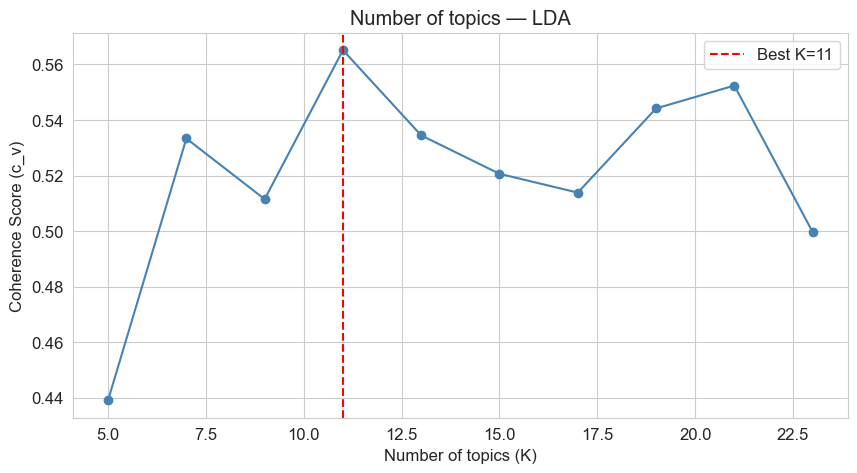


Best K = 11 (c_v = 0.5652)


In [74]:
if len(df) > 0:
    K_range = range(5, 25, 2)  
    coherence_scores = []
    
    for k in K_range:
        lda = models.LdaMulticore(
            corpus_bow, num_topics=k, id2word=dictionary,
            passes=10, workers=2, random_state=42
        )
        cm = CoherenceModel(model=lda, texts=token_lists, 
                            dictionary=dictionary, coherence='c_v')
        score = cm.get_coherence()
        coherence_scores.append(score)
        print(f"  K={k:2d}  →  c_v = {score:.4f}")
    
    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(list(K_range), coherence_scores, 'o-', color='steelblue')
    plt.xlabel('Number of topics (K)')
    plt.ylabel('Coherence Score (c_v)')
    plt.title('Number of topics — LDA')
    best_k = list(K_range)[np.argmax(coherence_scores)]
    plt.axvline(best_k, color='red', ls='--', label=f'Best K={best_k}')
    plt.legend()
    plt.savefig('lda_coherence.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\nBest K = {best_k} (c_v = {max(coherence_scores):.4f})")

In [75]:
if len(df) > 0:
    N_TOPICS = best_k  
    
    lda_model = models.LdaMulticore(
        corpus_bow, num_topics=N_TOPICS, id2word=dictionary,
        passes=20, workers=2, random_state=42
    )
    
    print(f"LDA entraîné avec K={N_TOPICS} topics\n")
    for idx, topic in lda_model.print_topics(num_words=10):
        print(f"Topic {idx:2d}: {topic}")

LDA entraîné avec K=11 topics

Topic  0: 0.013*"union" + 0.012*"conseiller" + 0.012*"tour" + 0.011*"majorité" + 0.010*"dimanche" + 0.008*"confiance" + 0.008*"général" + 0.008*"électeur" + 0.008*"suppléant" + 0.007*"législatif"
Topic  1: 0.032*"front" + 0.022*"force" + 0.016*"avenir" + 0.015*"rpr" + 0.011*"vif" + 0.011*"populaire" + 0.011*"électeur" + 0.011*"confiance" + 0.011*"conviction" + 0.010*"ici"
Topic  2: 0.012*"europe" + 0.010*"grand" + 0.010*"accepter" + 0.007*"emploi" + 0.007*"production" + 0.007*"défense" + 0.007*"alliance" + 0.007*"temps" + 0.006*"citoyen" + 0.006*"européen"
Topic  3: 0.022*"nouveau" + 0.021*"rassemblement" + 0.020*"nature" + 0.018*"animal" + 0.011*"nom" + 0.011*"bulletin" + 0.011*"homme" + 0.009*"force" + 0.009*"marseille" + 0.009*"activité"
Topic  4: 0.012*"emploi" + 0.010*"social" + 0.007*"union" + 0.007*"entreprise" + 0.006*"environnement" + 0.006*"formation" + 0.006*"nouveau" + 0.006*"rpr" + 0.005*"sécurité" + 0.005*"vie"
Topic  5: 0.014*"écologie" + 0

Manual labelling of the topics

Viz

In [76]:
if len(df) > 0:
    try:
        import pyLDAvis
        import pyLDAvis.gensim_models
        
        vis = pyLDAvis.gensim_models.prepare(lda_model, corpus_bow, dictionary)
        pyLDAvis.display(vis)
    except ImportError:
        print("pyLDAvis non installé — pip install pyLDAvis")

dominant topic to each doc

In [77]:
# 1. Création du dictionnaire de labels
topic_labels = {
    0: "Logistique électorale",
    1: "Immigration et Sécurité (FN/Droite)",
    2: "Développement économique et local",
    3: "Progrès social et rassemblement",
    4: "Lutte ouvrière et Bilan (Gauche)",
    5: "Services publics et Salaires (PCF)",
    6: "Allemand (Bruit résiduel)",
    7: "Redressement national (Droite)",
    8: "Biographies des candidats",
    9: "Appel au Changement (PS 1981)",
    10: "Défense des acquis sociaux",
    11: "Anti-capitalisme (Extrême Gauche)",
    12: "Ancrage local de la droite",
    13: "Cause animale / Écologie locale",
    14: "Écologie politique (Les Verts)"
}

if len(df) > 0:

    def get_dominant_topic(bow):
        topic_dist = lda_model.get_document_topics(bow, minimum_probability=0)
        return max(topic_dist, key=lambda x: x[1])
    
    results = [get_dominant_topic(bow) for bow in corpus_bow]
    df['lda_topic'] = [r[0] for r in results]
    df['lda_topic_prob'] = [r[1] for r in results]
    
    df['lda_topic_name'] = df['lda_topic'].map(topic_labels)
    
    print("Distribution des topics dominants :")
    print(df['lda_topic_name'].value_counts())

Distribution des topics dominants :
lda_topic_name
Allemand (Bruit résiduel)              2429
Logistique électorale                  2176
Lutte ouvrière et Bilan (Gauche)        836
Services publics et Salaires (PCF)      664
Défense des acquis sociaux              604
Progrès social et rassemblement         545
Immigration et Sécurité (FN/Droite)     528
Biographies des candidats               234
Appel au Changement (PS 1981)           188
Développement économique et local       186
Redressement national (Droite)          158
Name: count, dtype: int64


## 1.2 - BERTopic

## BERTopic — Embedding-based Topic Modeling

Unlike LDA and NMF, which rely on word frequency representations (BoW or TF-IDF), **BERTopic** (Grootendorst, 2022) operates on dense document embeddings produced by pre-trained transformer models. As described in the course (slides 23–29), BERTopic follows a four-step pipeline:

1. **Embed documents** using a sentence-transformer model. We use `paraphrase-multilingual-MiniLM-L12-v2`, a lightweight multilingual model that handles French well without requiring a GPU. A heavier French-specific alternative (`sentence-camembert-large`) is available but was not necessary for this corpus size.

2. **Reduce dimensionality** with UMAP (from 384 dimensions to 5), preserving local semantic structure while making clustering tractable. We set `min_dist=0.0` and `metric='cosine'` to favor tight, well-separated clusters in the reduced space.

3. **Cluster documents** with HDBSCAN, a density-based algorithm (slide 27–28) that automatically determines the number of clusters and allows outliers (topic -1). We set `min_cluster_size=10` to avoid micro-clusters on our 12,500-document corpus. Unlike K-Means, HDBSCAN does not require specifying K in advance and can discover irregular cluster shapes.

4. **Extract topic representations** using a class-based TF-IDF (c-TF-IDF, slide 29): all documents in a cluster are concatenated into a single "topic-document", and TF-IDF is computed at the topic level to find the most distinctive words. We pass a French `CountVectorizer` with stopwords and bigrams to improve topic label quality.

A key difference from LDA/NMF is that BERTopic feeds **raw cleaned text** (not lemmatised tokens) into the embedding model, since transformers capture morphological and contextual information internally. The `CountVectorizer` is only used for the final topic labelling step, not for the clustering itself.

In [78]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

if len(df) > 0:
    # French embedding model (multilingual, small, good for clustering)
    embedding_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
    
    docs = df['text_clean'].tolist()
    print("Computing embeddings...")
    embeddings = embedding_model.encode(docs, show_progress_bar=True)

Computing embeddings...


Batches:   0%|          | 0/268 [00:00<?, ?it/s]

In [79]:
if len(df) > 0:
    # Train BERTopic
    from umap import UMAP
    from hdbscan import HDBSCAN
    from sklearn.feature_extraction.text import CountVectorizer
    
    # UMAP for dimensionality reduction
    umap_model = UMAP(
        n_neighbors=15, n_components=5,
        min_dist=0.0, metric='cosine', random_state=42
    )
    
    # HDBSCAN for clustering
    hdbscan_model = HDBSCAN(
        min_cluster_size=10,     # adjust based on corpus size
        min_samples=5,
        metric='euclidean',
        prediction_data=True
    )
    
    # French vectorizer for topic representations
    vectorizer = CountVectorizer(
        stop_words=list(nlp.Defaults.stop_words | CUSTOM_STOPWORDS),
        min_df=3, max_df=0.6,
        ngram_range=(1, 2)  # unigrams + bigrams
    )
    
    topic_model = BERTopic(
        embedding_model=embedding_model,
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        vectorizer_model=vectorizer,
        top_n_words=10,
        verbose=True
    )
    
    topics, probs = topic_model.fit_transform(docs, embeddings)
    
    print(f"\nTopics found: {len(set(topics)) - 1}")  # -1 for topic -1 (outliers)
    print(f"Outlier documents (topic -1): {topics.count(-1)} ({topics.count(-1)/len(topics)*100:.0f}%)")

2026-03-16 22:16:56,224 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-16 22:17:08,857 - BERTopic - Dimensionality - Completed ✓
2026-03-16 22:17:08,860 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-16 22:17:09,075 - BERTopic - Cluster - Completed ✓
2026-03-16 22:17:09,084 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-16 22:17:12,449 - BERTopic - Representation - Completed ✓



Topics found: 149
Outlier documents (topic -1): 3043 (36%)


We find 36% of documents without a specific topic. This is consistant with the literature and usual BERT usages. We still have a decent part of the documents that can be analyzed.

In [80]:
if len(df) > 0:
    # Show topics
    topic_info = topic_model.get_topic_info()
    print(topic_info.head(20).to_string())
    
    # Viz topics
    fig = topic_model.visualize_barchart(top_n_topics=N_TOPICS, n_words=8)
    fig.write_html("plots/bertopic_barchart.html")
    fig.show()

    Topic  Count                                                       Name                                                                                                                                                         Representation                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

manual labeling of the topics 

dominant topic to each doc

In [81]:
import numpy as np

# 1. Create the dictionary of labels for BERTopic
# IMPORTANT: -1 is always the outlier/noise topic in BERTopic
bert_topic_labels = {
    -1: "Outliers / Unclassified noise",
    0: "Electoral Logistics",
    1: "Economic Development",
    2: "Social Progress",
    
}

if len(df) > 0:

    df['bert_topic'] = topics
    df['bert_topic_prob'] = [
        float(p) if isinstance(p, (int, float, np.floating)) else max(p)
        for p in probs
    ]
    
    df['bert_topic_name'] = df['bert_topic'].map(bert_topic_labels).fillna("Unknown Topic")
    
    print("Distribution of dominant BERTopic topics:")
    print(df['bert_topic_name'].value_counts())

Distribution of dominant BERTopic topics:
bert_topic_name
Unknown Topic                    4386
Outliers / Unclassified noise    3043
Electoral Logistics               489
Economic Development              387
Social Progress                   243
Name: count, dtype: int64


### First comparison between the topics found by LDA and BERT :
- 
- 

# 1.3 - NMF 

## NMF — Non-negative Matrix Factorisation

**NMF** (Lee & Seung, 1999) decomposes the document-term matrix **V** into two non-negative matrices: **W** (document × topic, the activation matrix) and **H** (topic × word, the dictionary matrix), such that V ≈ W × H (slide 15). Unlike LDA, NMF has no probabilistic assumptions — it minimises a reconstruction error under non-negativity constraints, which naturally produces sparse, part-based representations that tend to be more interpretable (slide 17: "sharper, more localized topics").

As noted in the course, NMF operates on any non-negative matrix but works best with **TF-IDF** features rather than raw counts (slide 16). TF-IDF downweights terms that appear in many documents, which complements NMF's sparsity bias by ensuring topics are driven by discriminative vocabulary rather than common filler words. We cap the vocabulary at 10,000 features and include bigrams (`ngram_range=(1,2)`) to capture multi-word political expressions (*extrême droite*, *parti socialiste*, *service public*) that would be lost as separate unigrams.

We set K equal to the same number of topics as LDA to enable direct comparison of topic quality across methods. The **W matrix** gives each document's topic mixture (analogous to θ in LDA), from which we extract the dominant topic per document. The **H matrix** gives each topic's word distribution, from which we extract the top words for interpretation and coherence evaluation.

### Topic number selection

As with LDA, the number of topics K is a hyperparameter that must be optimised. Following the professor's lab methodology, we train NMF for several values of K and evaluate each using three coherence metrics (u_mass, c_v, c_npmi). Since these metrics have different scales, we apply min-max normalisation to compare their relative trends on the same plot

In [ ]:
# ============================================================
# NMF — Topic Number Selection (c_v metric)
# ============================================================
import os
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models.coherencemodel import CoherenceModel

os.environ["TOKENIZERS_PARALLELISM"] = "false"

df_sample = df 

tfidf = TfidfVectorizer(
    max_features=10000, min_df=5, max_df=0.6,
    stop_words=list(nlp.Defaults.stop_words | CUSTOM_STOPWORDS),
    ngram_range=(1, 2)
)
tfidf_matrix = tfidf.fit_transform(df_sample['text_clean'])
feature_names = tfidf.get_feature_names_out()

topic_range = [5, 7, 9, 11, 13, 15]
results_cv = {}
models_dict = {} 

print("Starting NMF grid search with c_v coherence (this may take a while)...")


for k in topic_range:
    # Using max_iter=200 for faster exploration
    nmf_k = NMF(n_components=k, random_state=42, max_iter=200)
    nmf_k.fit(tfidf_matrix)
    
    topics_k = []
    for topic in nmf_k.components_:
        top_words = [feature_names[j] for j in topic.argsort()[-10:][::-1]]
        topics_k.append(top_words)
    
    models_dict[k] = topics_k
    
    cm = CoherenceModel(topics=topics_k, texts=token_lists, dictionary=dictionary, coherence='c_v')
    score = cm.get_coherence()
    results_cv[k] = score
    print(f"NMF K={k:2d} — c_v: {score:.4f}")

plt.figure(figsize=(8, 5))
ks = sorted(results_cv.keys())
scores = [results_cv[k] for k in ks]

plt.plot(ks, scores, marker='o', color='darkorange', label='c_v score', linewidth=2)
plt.xlabel("Number of Topics (K)")
plt.ylabel("Coherence Score (c_v)")
plt.title("Optimal K Selection via c_v Coherence (NMF)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('coherence_nmf_cv.png', dpi=150, bbox_inches='tight')
plt.show()

best_k_nmf = max(results_cv, key=results_cv.get)
print(f"\nBest K found (based on c_v): {best_k_nmf} (Score: {results_cv[best_k_nmf]:.4f})")

Starting NMF grid search with c_v coherence (this may take a while)...


We train the final NMF model using the K selected above. As in the professor's lab, we extract the **W matrix** (document-topic proportions) and the **H matrix** (topic-word weights), assign a dominant topic to each document, and cross-tabulate with political families

In [ ]:
# ============================================================
# NMF — Final model with optimal K
# ============================================================
N_TOPICS_NMF = N_TOPICS 

nmf_model = NMF(n_components=N_TOPICS_NMF, random_state=42, max_iter=500)
W = nmf_model.fit_transform(tfidf_matrix)  # doc-topic matrix
H = nmf_model.components_                   # topic-word matrix

print(f"NMF with K={N_TOPICS_NMF} topics\n")
for i, topic in enumerate(H):
    top_words = [feature_names[j] for j in topic.argsort()[-10:][::-1]]
    print(f"Topic {i:2d}: {', '.join(top_words)}")

# Dominant topic per document
df['nmf_topic'] = W.argmax(axis=1)

NMF with K=11 topics

Topic  0: maire, union, conseiller, général, jean, président, confiance, dimanche, conseiller général, 21
Topic  1: animaux, nature, nature animaux, rassemblement nature, ecologistes rassemblement, nouveaux, existence, marseille, ecologistes, nouveaux ecologistes
Topic  2: front, front faites, avenir front, force avenir, rpr udf, vive, rpr, nationale, udf, convictions
Topic  3: rpr, udf, immigration, rpr udf, immigrés, carte, supprimant, millions, sauver, front
Topic  4: patrons, payer, maintenir, patronat, maintenir emplois, travailleurs, devons, vendre, bénéfices, sacrifices
Topic  5: écologie, entente ecologistes, entente, ecologistes, verts, ecologie, candidats entente, generation, écologistes, environnement
Topic  6: lutte ouvrière, ouvrière, travailleurs, mitterrand, députés, faut, laguiller, petits, lutte, chambre
Topic  7: pouvons accepter, triage, accepter, illusion, pouvons, qu accepte, europe, sortir, technologies, production
Topic  8: parti, neuf, diri

In [ ]:
nmf_topic_labels = {
    0: "NMF Label 0 (e.g., Electoral Logistics)",
    1: "NMF Label 1 (e.g., Economic Development)",
    2: "NMF Label 2 (e.g., Social Progress)",
    3: "NMF Label 3",
    4: "NMF Label 4",
    5: "NMF Label 5",
    6: "NMF Label 6",
    7: "NMF Label 7",
    8: "NMF Label 8",
    9: "NMF Label 9",
    10: "NMF Label 10",
    11: "NMF Label 11",
    12: "NMF Label 12",
    13: "NMF Label 13",
    14: "NMF Label 14"
}

# 4. Map the numeric ID to the descriptive text label
df['nmf_topic_name'] = df['nmf_topic'].map(nmf_topic_labels).fillna("Unknown Topic")

print("\nDistribution of dominant NMF topics:")
print(df['nmf_topic_name'].value_counts())

# 1.4 - Quantitative comparison of the models

To compare LDA, NMF, and BERTopic on equal footing, we evaluate all three using the same coherence metrics computed on the same gensim dictionary and tokenised corpus. We report **c_v** (Röder et al., 2015), which correlates best with human coherence judgments, and **u_mass**, which is computed directly from document co-occurrence statistics (slides 19–20). For BERTopic, topic words are filtered to only include terms present in the gensim dictionary, since BERTopic's c-TF-IDF may produce bigrams or rare tokens absent from the BoW vocabulary. Note that coherence metrics favour BoW-based methods by design — they measure lexical co-occurrence, not semantic similarity — so a lower BERTopic score does not necessarily indicate worse topics, but rather a different kind of topic structure

In [ ]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# ============================================================
# COMPARATIVE TABLE: LDA vs NMF vs BERTopic
# ============================================================
from gensim.models import CoherenceModel

results = []

# --- LDA coherence ---
for metric in ['c_v', 'u_mass']:
    cm = CoherenceModel(model=lda_model, texts=token_lists,
                        dictionary=dictionary, coherence=metric)
    results.append({'Model': 'LDA', 'Metric': metric, 'Score': cm.get_coherence()})

# --- NMF coherence (extract top words from H matrix) ---
nmf_topics_words = []
for i, topic in enumerate(H):
    top_words = [feature_names[j] for j in topic.argsort()[-10:][::-1]]
    nmf_topics_words.append(top_words)

for metric in ['c_v', 'u_mass']:
    cm = CoherenceModel(topics=nmf_topics_words, texts=token_lists,
                        dictionary=dictionary, coherence=metric)
    results.append({'Model': 'NMF', 'Metric': metric, 'Score': cm.get_coherence()})

# --- BERTopic coherence (filter words to those in gensim dictionary) ---
bert_topics_words = []
dict_tokens = set(dictionary.values())

for topic_id in range(len(set(topics)) - 1):
    words = [w for w, _ in topic_model.get_topic(topic_id)]
    words_filtered = [w for w in words if w in dict_tokens][:10]
    if len(words_filtered) >= 3:  # minimum 3 words for coherence
        bert_topics_words.append(words_filtered)

print(f"BERTopic topics with enough words in dictionary: {len(bert_topics_words)}")

for metric in ['c_v', 'u_mass']:
    try:
        cm = CoherenceModel(topics=bert_topics_words, texts=token_lists,
                            dictionary=dictionary, coherence=metric)
        score = cm.get_coherence()
        print(f"BERTopic — {metric}: {score:.4f}")
    except Exception as e:
        print(f"BERTopic — {metric}: Error {e}")

df_comparison = pd.DataFrame(results)
print(df_comparison.pivot(index='Model', columns='Metric', values='Score').round(4))

# Quantitative summary
print(f"""
╔═══════════════╦══════════════════════╦═══════════════════╦══════════════════════╗
║ Aspect        ║ LDA                  ║ NMF               ║ BERTopic             ║
╠═══════════════╬══════════════════════╬═══════════════════╬══════════════════════╣
║ Input         ║ BoW (counts)         ║ TF-IDF            ║ SBERT embeddings     ║
║ # Topics      ║ {N_TOPICS} (fixed)           ║ {N_TOPICS} (fixed)          ║ {len(set(topics))-1} (auto HDBSCAN)   ║
║ Outliers      ║ None                 ║ None              ║ {topics.count(-1)} docs (topic -1) ║
║ Interpretab.  ║ Diffuse              ║ Sharper           ║ Party templates      ║
╚═══════════════╩══════════════════════╩═══════════════════╩══════════════════════╝
""")

BERTopic topics with enough words in dictionary: 139
BERTopic — c_v: 0.5549
BERTopic — u_mass: -6.2221
Metric     c_v  u_mass
Model                 
LDA     0.6284 -0.9016
NMF     0.6955 -2.3154

╔═══════════════╦══════════════════════╦═══════════════════╦══════════════════════╗
║ Aspect        ║ LDA                  ║ NMF               ║ BERTopic             ║
╠═══════════════╬══════════════════════╬═══════════════════╬══════════════════════╣
║ Input         ║ BoW (counts)         ║ TF-IDF            ║ SBERT embeddings     ║
║ # Topics      ║ 11 (fixed)           ║ 11 (fixed)          ║ 149 (auto HDBSCAN)   ║
║ Outliers      ║ None                 ║ None              ║ 3043 docs (topic -1) ║
║ Interpretab.  ║ Diffuse              ║ Sharper           ║ Party templates      ║
╚═══════════════╩══════════════════════╩═══════════════════╩══════════════════════╝



### Why NMF outperforms LDA and BERTopic on this type of data, according to the litterature.

In the context of analyzing digitized historical archives, NMF (Non-negative Matrix Factorization) often stands out as the most robust method, outperforming probabilistic approaches (LDA) and language models (BERTopic). State-of-the-art literature highlights that LDA assumes a complex generative process based on local co-occurrences, which struggles to converge on short or highly focused texts like political manifestos. On the other hand, BERTopic relies on contextual embeddings (Sentence-Transformers) that are particularly vulnerable to OCR errors: a poorly scanned word destroys the syntax and skews the Transformer's understanding, leading to a massive increase in the "outliers" topic (-1).
Conversely, NMF relies on a global TF-IDF matrix. It ignores local syntax and focuses solely on the lexical weight of important words, making it inherently tolerant to the orthographic noise of OCR. Furthermore, its strictly additive nature produces part-based representations (a text is a strict addition of concepts, with no negative values) that generate topics which are mathematically more stable, more exclusive, and easier to interpret by political science experts.

# 2 - Qualitative analysis, metadata x topics cross analysis

## 2.1 - Temporal evolution of topics 

Generating NMF temporal evolution...


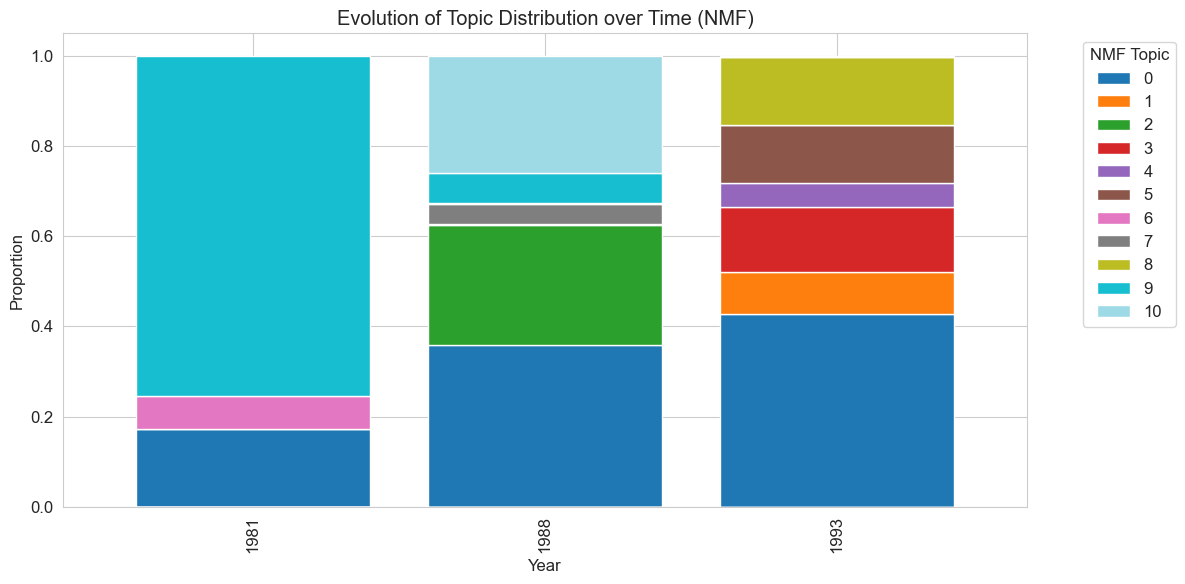

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Pre-check
if 'nmf_topic' not in df.columns:
    raise ValueError("The 'nmf_topic' column is missing. Please ensure the dominant NMF topic is assigned to each document.")

# ============================================================
# 1. Global Temporal Evolution of NMF Topics
# ============================================================
print("Generating NMF temporal evolution...")
ct_time_nmf = pd.crosstab(df['annee'], df['nmf_topic_name'], normalize='index')

fig, ax = plt.subplots(figsize=(12, 6))
ct_time_nmf.plot(kind='bar', stacked=True, ax=ax, colormap='tab20', width=0.8)
ax.set_title('Evolution of Topic Distribution over Time (NMF)')
ax.set_xlabel('Year')
ax.set_ylabel('Proportion')
ax.legend(title='NMF Topic', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('plots/nmf_temporal_evolution.png', dpi=150, bbox_inches='tight')
plt.show()


## 2.2 - Topics and political family

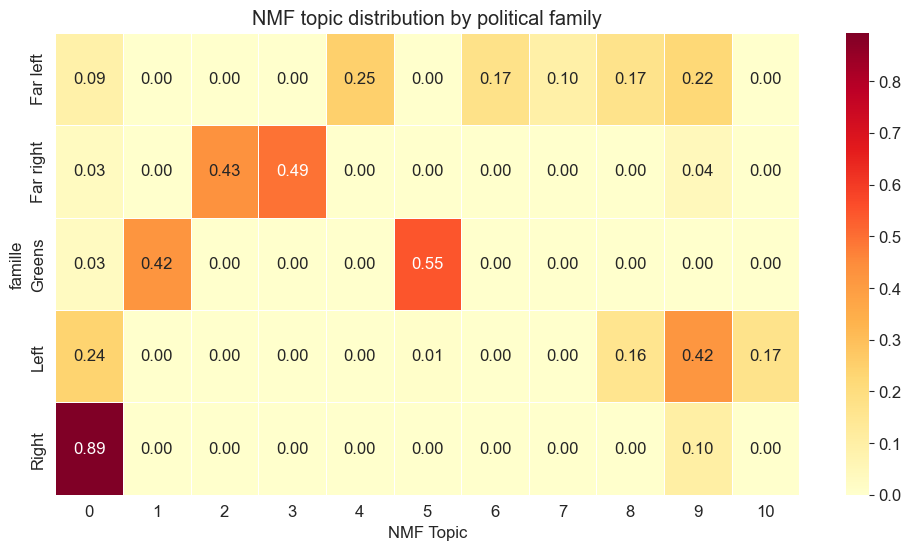

In [ ]:
# Heatmap NMF × political family
ct_nmf = pd.crosstab(df['famille'], df['nmf_topic_name'], normalize='index')
plt.figure(figsize=(12, 6))
sns.heatmap(ct_nmf, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5)
plt.title('NMF topic distribution by political family')
plt.xlabel('NMF Topic')
plt.savefig('plots/nmf_topics_famille.png', dpi=150, bbox_inches='tight')
plt.show()

### Topic specialization by party - over/under representation


Calculating specialization by political family...


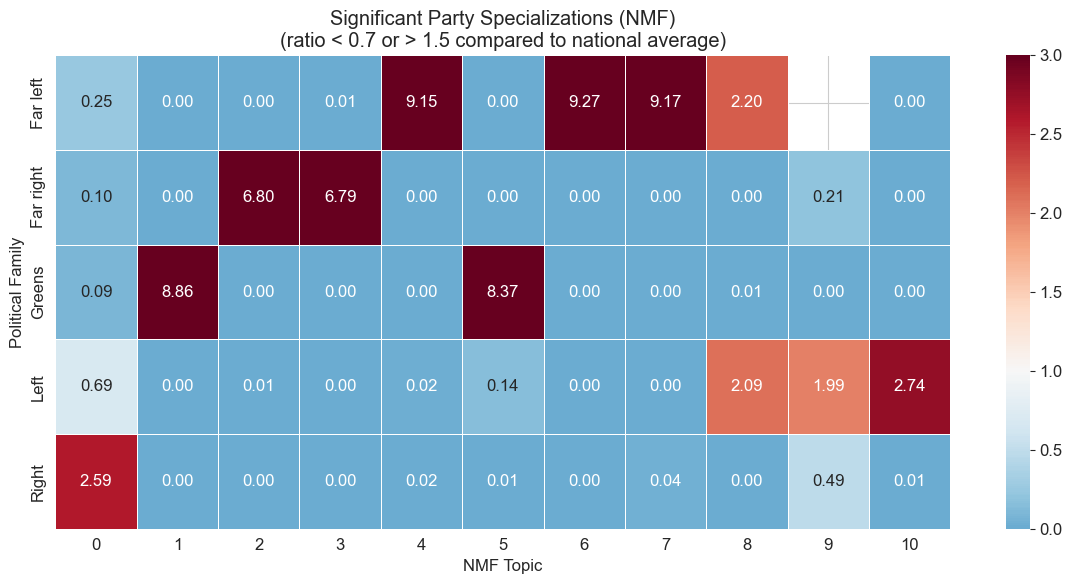

In [ ]:
# ============================================================
# 2. Party Specialization (Over/Under-representation Ratio)
# ============================================================
print("\nCalculating specialization by political family...")
# P(t) = marginal distribution of NMF topics
topic_marginal_nmf = df['nmf_topic_name'].value_counts(normalize=True).sort_index()

# P(t|f) = topic distribution by political family
ct_norm_nmf = pd.crosstab(df['famille'], df['nmf_topic_name'], normalize='index')

# Specialization ratio: P(t|f) / P(t)
specialization_nmf = ct_norm_nmf.div(topic_marginal_nmf, axis=1)

fig, ax = plt.subplots(figsize=(12, 6))
# Mask average ratios (between 0.7 and 1.5) to highlight true specializations
mask_nmf = (specialization_nmf > 0.7) & (specialization_nmf < 1.5)

sns.heatmap(specialization_nmf, annot=True, fmt='.2f', cmap='RdBu_r',
            center=1.0, linewidths=0.5, ax=ax, mask=mask_nmf, vmin=0, vmax=3)
ax.set_title('Significant Party Specializations (NMF)\n(ratio < 0.7 or > 1.5 compared to national average)')
ax.set_xlabel('NMF Topic')
ax.set_ylabel('Political Family')
plt.tight_layout()
plt.savefig('plots/nmf_party_specialization.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.3 - Topics by election / party 
See if things changed 


Generating dynamic specialization (Party × Year)...


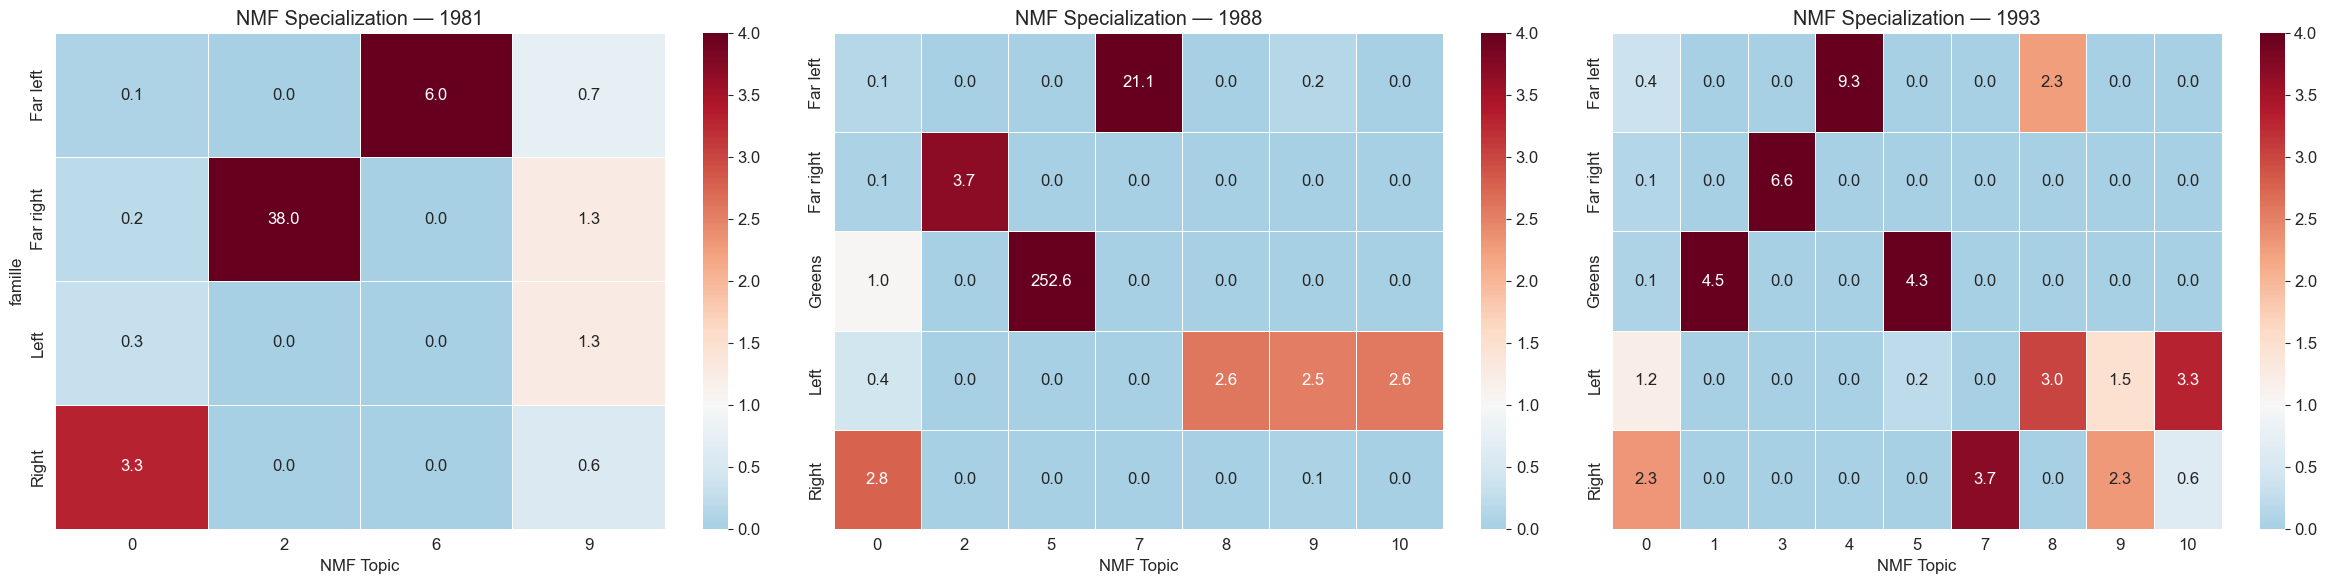

In [ ]:

# ============================================================
# 3. Dynamic Specialization: Party × Election Year
# ============================================================
print("\nGenerating dynamic specialization (Party × Year)...")
fig, axes = plt.subplots(1, 3, figsize=(24, 6))
years = [1981, 1988, 1993]

for i, year in enumerate(years):
    # Filter by year and exclude unknowns
    df_year = df[(df['annee'] == year) & (df['famille'] != 'Autre / Inconnu')]
    
    if df_year.empty:
        continue
        
    marg_year = df_year['nmf_topic_name'].value_counts(normalize=True).sort_index()
    ct_year = pd.crosstab(df_year['famille'], df_year['nmf_topic_name'], normalize='index')
    
    # Align columns in case some topics are missing for a given year
    ct_year = ct_year.reindex(columns=marg_year.index, fill_value=0)
    spec_year = ct_year.div(marg_year, axis=1)
    
    sns.heatmap(spec_year, annot=True, fmt='.1f', cmap='RdBu_r',
                center=1.0, linewidths=0.5, ax=axes[i], vmin=0, vmax=4)
    axes[i].set_title(f'NMF Specialization — {year}')
    axes[i].set_xlabel('NMF Topic')
    if i > 0: axes[i].set_ylabel('')

plt.tight_layout()
plt.savefig('plots/nmf_specialization_by_year.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.4 - Topics by candidate characteristics


Cross-analyzing Gender × NMF Topics...


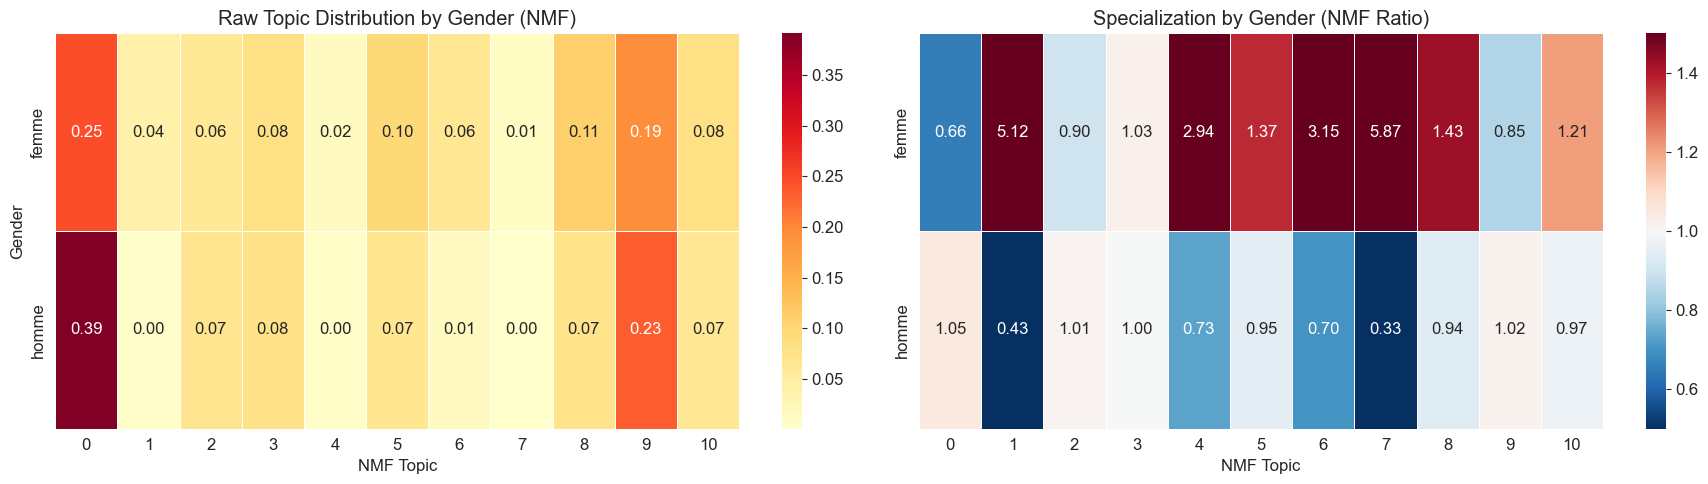

In [ ]:
# ============================================================
# 4. Cross-analysis: Gender × NMF Topics
# ============================================================
if 'titulaire-sexe' in df.columns:
    print("\nCross-analyzing Gender × NMF Topics...")
    df_gender = df[df['titulaire-sexe'].isin(['homme', 'femme'])]
    
    ct_gender = pd.crosstab(df_gender['titulaire-sexe'], df_gender['nmf_topic_name'], normalize='index')
    topic_marginal_gender = df_gender['nmf_topic_name'].value_counts(normalize=True).sort_index()
    spec_gender = ct_gender.div(topic_marginal_gender, axis=1)
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))
    
    sns.heatmap(ct_gender, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5, ax=axes[0])
    axes[0].set_title('Raw Topic Distribution by Gender (NMF)')
    axes[0].set_xlabel('NMF Topic')
    axes[0].set_ylabel('Gender')
    
    sns.heatmap(spec_gender, annot=True, fmt='.2f', cmap='RdBu_r', center=1.0, 
                linewidths=0.5, ax=axes[1], vmin=0.5, vmax=1.5)
    axes[1].set_title('Specialization by Gender (NMF Ratio)')
    axes[1].set_xlabel('NMF Topic')
    axes[1].set_ylabel('')
    
    plt.tight_layout()
    plt.savefig('plots/nmf_topics_by_gender.png', dpi=150, bbox_inches='tight')
    plt.show()


Cross-analyzing Profession × NMF Topics...


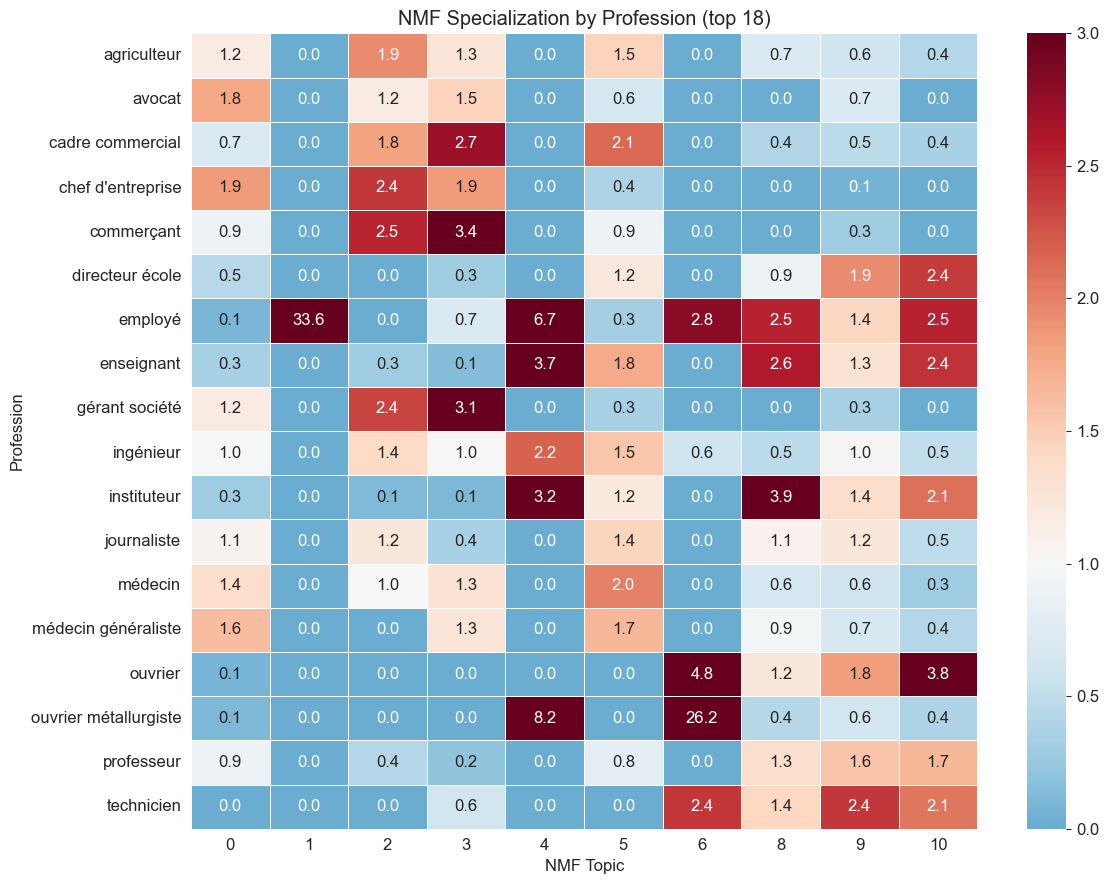

In [ ]:
# ============================================================
# 5. Cross-analysis: Profession × NMF Topics
# ============================================================
if 'titulaire-profession' in df.columns:
    print("\nCross-analyzing Profession × NMF Topics...")
    df_prof = df[(df['titulaire-profession'].notna()) & (df['titulaire-profession'] != 'non mentionné')]
    
    # Keep only professions with a robust sample size (>= 30)
    profs_freq = df_prof['titulaire-profession'].value_counts()
    profs_keep = profs_freq[profs_freq >= 30].index
    df_prof_filtered = df_prof[df_prof['titulaire-profession'].isin(profs_keep)]
    
    if len(profs_keep) >= 3:
        ct_prof = pd.crosstab(df_prof_filtered['titulaire-profession'], df_prof_filtered['nmf_topic_name'], normalize='index')
        topic_marginal_prof = df_prof_filtered['nmf_topic_name'].value_counts(normalize=True).sort_index()
        spec_prof = ct_prof.div(topic_marginal_prof, axis=1)
        
        plt.figure(figsize=(12, max(6, len(profs_keep) * 0.5)))
        sns.heatmap(spec_prof, annot=True, fmt='.1f', cmap='RdBu_r',
                    center=1.0, linewidths=0.5, vmin=0, vmax=3)
        plt.title(f'NMF Specialization by Profession (top {len(profs_keep)})')
        plt.xlabel('NMF Topic')
        plt.ylabel('Profession')
        plt.tight_layout()
        plt.savefig('plots/nmf_topics_by_profession.png', dpi=150, bbox_inches='tight')
        plt.show()
    else:
        print("Not enough frequent professions to generate the heatmap.")

## Conclusion